# Load Model

In [1]:
from ultralytics import YOLO

In [2]:
model = YOLO("yolo11n.pt")

# Fine-Tuning

In [3]:
result = model.train(data='./data.yaml',  epochs=10, imgsz=320, batch=128)

New https://pypi.org/project/ultralytics/8.4.114 available 😃 Update with 'pip install -U ultralytics'
Ultralytics 8.4.101 🚀 Python-3.13.9 torch-2.13.0+cu130 CUDA:0 (NVIDIA GeForce RTX 5060 Laptop GPU, 8151MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=128, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=./data.yaml, degrees=0.0, deterministic=True, device=, dfl=1.5, dis=6.0, distill_model=None, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=10, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=320, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11n.pt, momentum=0.937, mosaic=1.

In [4]:
result.results_dict

{'metrics/precision(B)': 0.9965616125790699,
 'metrics/recall(B)': 0.9992534085743358,
 'metrics/mAP50(B)': 0.995,
 'metrics/mAP50-95(B)': 0.9067040513510887,
 'fitness': 0.9067040513510887}

In [5]:
0.1 * 0.9940630907213551 + 0.1*0.9984916821905125 + 0.4*0.995 + 0.4*0.9187812255846218

0.9647679675250356

In [6]:
0.1 * 0.995 + 0.9 * 0.9187812255846218

0.9264031030261597

# Load Best Model

In [7]:
best_model = YOLO('runs/detect/train/weights/best.pt')

In [8]:
metrics_val = best_model.val(data='data.yaml', split='val')

Ultralytics 8.4.101 🚀 Python-3.13.9 torch-2.13.0+cu130 CUDA:0 (NVIDIA GeForce RTX 5060 Laptop GPU, 8151MiB)
YOLO11n summary (fused): 101 layers, 2,582,737 parameters, 0 gradients, 6.3 GFLOPs
WARNING ⚠️ val: Slow image access detected (ping: 1.6±1.0 ms, read: 5.4±3.1 MB/s, size: 11.5 KB). Use local storage instead of remote/mounted storage for better performance. See https://docs.ultralytics.com/guides/model-training-tips/
val: Scanning /mnt/d/Computer-Vision/SSD-YOLO/YOLO/Yolo_dataset/labels/val.cache... 204 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 204/204 57.0Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 13/13 6.7it/s 1.9s0.1s
                   all        204        204      0.998      0.999      0.995      0.907
              airplane         80         80          1          1      0.995      0.901
                  face         44         44          1      0.999      0.995      0.921
            m

In [9]:
metrics_train = best_model.val(data='data.yaml', split='train')

Ultralytics 8.4.101 🚀 Python-3.13.9 torch-2.13.0+cu130 CUDA:0 (NVIDIA GeForce RTX 5060 Laptop GPU, 8151MiB)
WARNING ⚠️ val: Slow image access detected (ping: 3.6±1.7 ms, read: 1.6±0.2 MB/s, size: 8.4 KB). Use local storage instead of remote/mounted storage for better performance. See https://docs.ultralytics.com/guides/model-training-tips/
val: Scanning /mnt/d/Computer-Vision/SSD-YOLO/YOLO/Yolo_dataset/labels/train.cache... 1828 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 1828/1828 638.9Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 115/115 14.1it/s 8.1s0.1s
                   all       1828       1828      0.999          1      0.995      0.925
              airplane        719        719      0.999      0.999      0.995      0.904
                  face        391        391      0.999          1      0.995      0.942
            motorcycle        718        718      0.999          1      0.995      0.929

# Our Model Predict

In [10]:
results = best_model("yolo_dataset/images/val/airplane_image_0002.jpg")


image 1/1 /mnt/d/Computer-Vision/SSD-YOLO/YOLO/yolo_dataset/images/val/airplane_image_0002.jpg: 160x320 1 airplane, 37.3ms
Speed: 4.2ms preprocess, 37.3ms inference, 8.8ms postprocess per image at shape (1, 3, 160, 320)


In [11]:
results[0].boxes

ultralytics.engine.results.Boxes object with attributes:

cls: tensor([0.], device='cuda:0')
conf: tensor([0.8433], device='cuda:0')
data: tensor([[ 59.3282,  33.4528, 340.8543, 154.4950,   0.8433,   0.0000]], device='cuda:0')
id: None
is_track: False
orig_shape: (184, 401)
shape: torch.Size([1, 6])
xywh: tensor([[200.0912,  93.9739, 281.5261, 121.0423]], device='cuda:0')
xywhn: tensor([[0.4990, 0.5107, 0.7021, 0.6578]], device='cuda:0')
xyxy: tensor([[ 59.3282,  33.4528, 340.8543, 154.4950]], device='cuda:0')
xyxyn: tensor([[0.1480, 0.1818, 0.8500, 0.8396]], device='cuda:0')

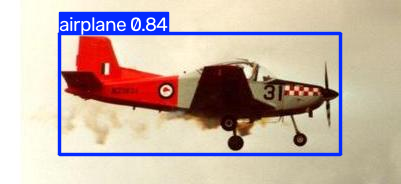

In [12]:
results[0].show()